/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN...
Training LSTM...
Training GRU...

Final Validation Losses:
RNN: 0.0053
LSTM: 0.0056
GRU: 0.0050


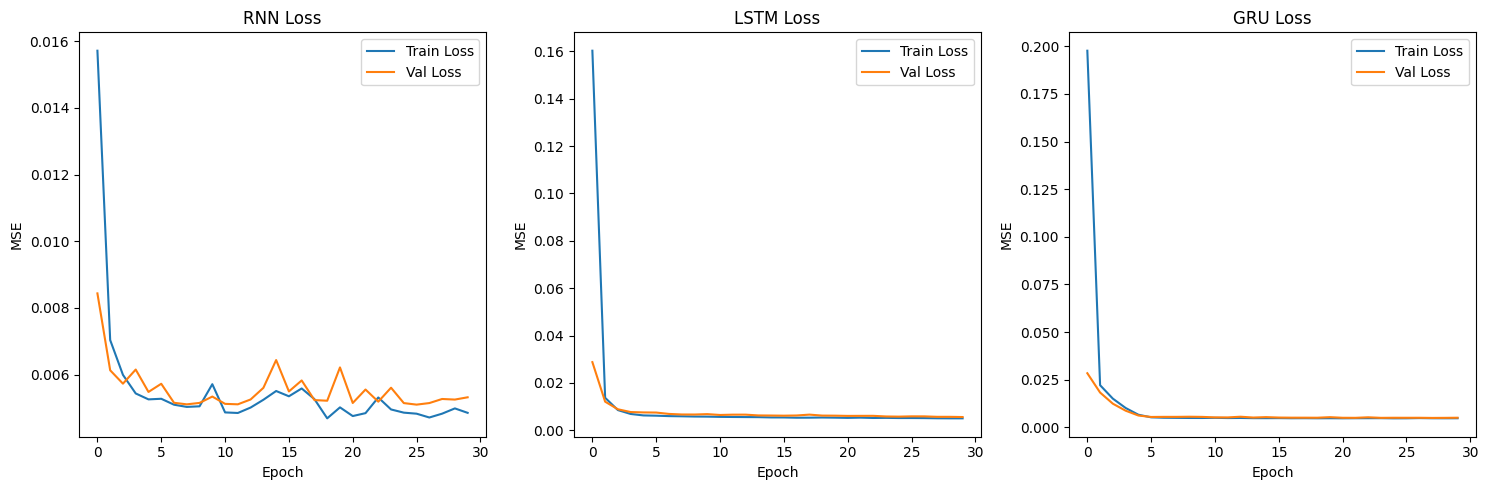

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

# 1. Load Data from Google Drive
# Extract the file ID from the sharing link
file_id = '1QeArnTI4ysR9cWMV3IZyxs_ZBx_MPWFm'
# Construct the direct download URL
url = f'https://drive.google.com/uc?id={file_id}'

print("Downloading and loading data...")
df = pd.read_csv(url)
data = df['TMIN'].values.reshape(-1, 1)

# 2. Scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Create Sequences
seq_len = 30
X, y = [], []
for i in range(seq_len, len(scaled_data)):
    X.append(scaled_data[i-seq_len:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# 4. Define Model Builder
def build_and_train_model(layer_type):
    model = Sequential()
    if layer_type == 'RNN':
        model.add(SimpleRNN(32, input_shape=(X_train.shape[1], 1)))
    elif layer_type == 'LSTM':
        model.add(LSTM(32, input_shape=(X_train.shape[1], 1)))
    elif layer_type == 'GRU':
        model.add(GRU(32, input_shape=(X_train.shape[1], 1)))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    print(f"Training {layer_type}...")
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    return history, model

# 5. Train Models
history_rnn, model_rnn = build_and_train_model('RNN')
history_lstm, model_lstm = build_and_train_model('LSTM')
history_gru, model_gru = build_and_train_model('GRU')

# 6. Final Validation Losses
print("\nFinal Validation Losses:")
print(f"RNN: {history_rnn.history['val_loss'][-1]:.4f}")
print(f"LSTM: {history_lstm.history['val_loss'][-1]:.4f}")
print(f"GRU: {history_gru.history['val_loss'][-1]:.4f}")

# 7. Plot
plt.figure(figsize=(15, 5))

# RNN Plot
plt.subplot(1, 3, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('RNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# LSTM Plot
plt.subplot(1, 3, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# GRU Plot
plt.subplot(1, 3, 3)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()